# LoRa Packet PHY: Framing, Redundancy, Interleaving, and Airtime

This standalone NumPy and Matplotlib tutorial follows the chirp-modulation notebook. It explains CRC, whitening, forward-error correction (FEC), interleaving, symbol packing, and airtime.

## 1. Packet path

~~~text
application payload -> CRC -> whitening -> FEC -> interleaving -> SF-bit symbols -> chirps
~~~

CRC detects damaged frames. Whitening avoids pathological bit patterns. FEC adds parity bits. Interleaving spreads a burst of errors over several codewords. Finally, SF bits select one cyclic chirp shift.

In [1]:
import binascii
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

BW_HZ = 812_500.0
PREAMBLE_SYMBOLS = 12
PAYLOAD = b"LoRa packet tutorial"

def bytes_to_bits(data):
    return np.unpackbits(np.frombuffer(data, dtype=np.uint8))

def crc16_ccitt(data):
    # Familiar CRC illustration; verify a target modem's CRC settings separately.
    return binascii.crc_hqx(data, 0xFFFF)

def append_crc(data):
    return data + crc16_ccitt(data).to_bytes(2, "big")

def verify_crc(frame):
    return crc16_ccitt(frame[:-2]) == int.from_bytes(frame[-2:], "big")

frame = append_crc(PAYLOAD)
print(f"payload bytes: {len(PAYLOAD)}, frame bytes after CRC: {len(frame)}")
print(f"CRC valid: {verify_crc(frame)}")

payload bytes: 20, frame bytes after CRC: 22
CRC valid: True


## 2. Whitening

Whitening XORs the frame with a repeatable pseudo-random sequence. XOR is its own inverse, so applying the same sequence again restores the original bits. The nine-bit LFSR below teaches that mechanism; it is not offered as the exact LoRa whitening sequence.

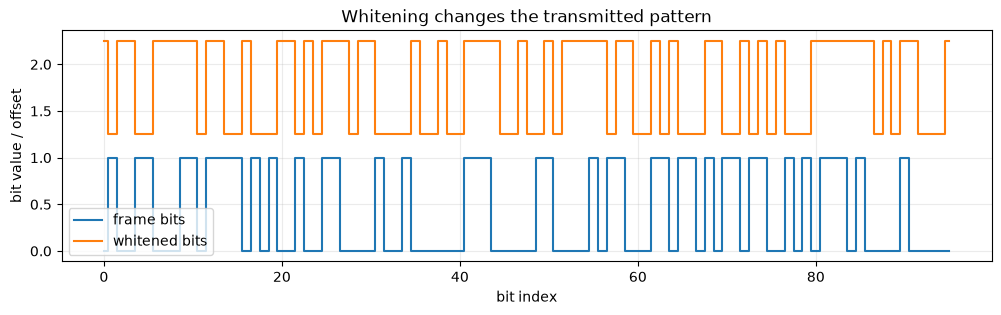

In [2]:
def pn9_bits(count, seed=0x1FF):
    state = seed
    output = np.empty(count, dtype=np.uint8)
    for i in range(count):
        output[i] = state & 1
        feedback = ((state >> 0) ^ (state >> 4)) & 1
        state = (state >> 1) | (feedback << 8)
    return output

def whiten(bits):
    return np.bitwise_xor(bits, pn9_bits(len(bits)))

frame_bits = bytes_to_bits(frame)
whitened_bits = whiten(frame_bits)
assert np.array_equal(whiten(whitened_bits), frame_bits)

fig, ax = plt.subplots(figsize=(12, 3))
count = min(96, len(frame_bits))
ax.step(np.arange(count), frame_bits[:count], where="mid", label="frame bits")
ax.step(np.arange(count), whitened_bits[:count] + 1.25, where="mid", label="whitened bits")
ax.set(title="Whitening changes the transmitted pattern", xlabel="bit index", ylabel="bit value / offset")
ax.legend()
plt.show()

## 3. FEC coding rate

For coding rate 4/n, four information bits are represented by n transmitted bits. The teaching encoder below is systematic: it keeps the four data bits and adds one to four parity bits. It preserves the exact overhead relationship, but its parity matrix is not the modem's proprietary implementation.

CR 4/5: 176 input bits -> 220 coded bits
CR 4/6: 176 input bits -> 264 coded bits
CR 4/7: 176 input bits -> 308 coded bits
CR 4/8: 176 input bits -> 352 coded bits


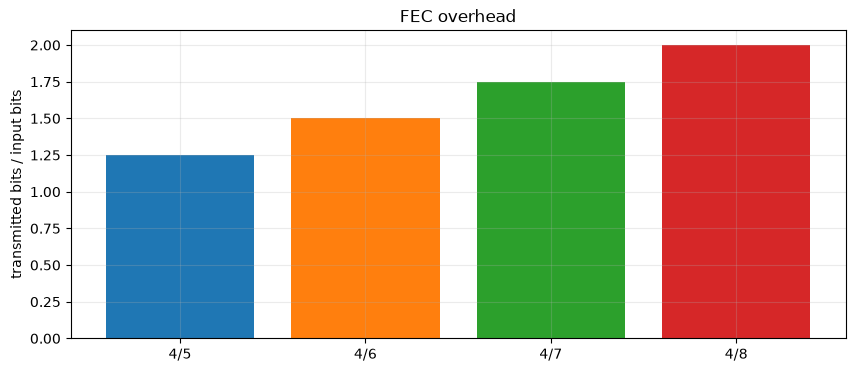

In [3]:
def fec_encode_4_n(bits, n=5):
    if n not in (5, 6, 7, 8):
        raise ValueError("n must be 5, 6, 7, or 8")
    padded = np.pad(bits, (0, (-len(bits)) % 4))
    blocks = padded.reshape(-1, 4)
    d0, d1, d2, d3 = blocks.T
    parity = np.column_stack((d0 ^ d1 ^ d2 ^ d3, d0 ^ d1 ^ d3, d0 ^ d2 ^ d3, d1 ^ d2 ^ d3))
    return np.column_stack((blocks, parity[:, :n - 4])).astype(np.uint8)

fig, ax = plt.subplots()
for n in (5, 6, 7, 8):
    encoded = fec_encode_4_n(whitened_bits, n)
    print(f"CR 4/{n}: {len(whitened_bits)} input bits -> {encoded.size} coded bits")
    ax.bar(f"4/{n}", encoded.size / len(whitened_bits), color=f"C{n - 5}")
ax.set(title="FEC overhead", ylabel="transmitted bits / input bits")
plt.show()

## 4. Interleaving, symbol packing, and airtime

The interleaver writes codewords as rows and transmits columns. A burst then damages one bit in several codewords rather than many bits in one. Grouping the outgoing bits in groups of SF yields integer chirp-shift indices from 0 to 2^SF - 1.

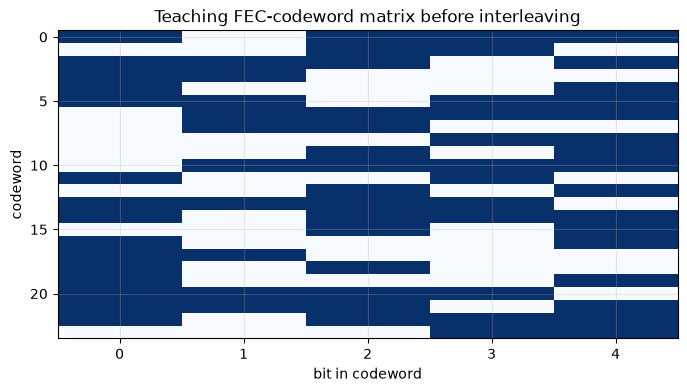

SF9: 220 interleaved bits -> 25 chirp symbols


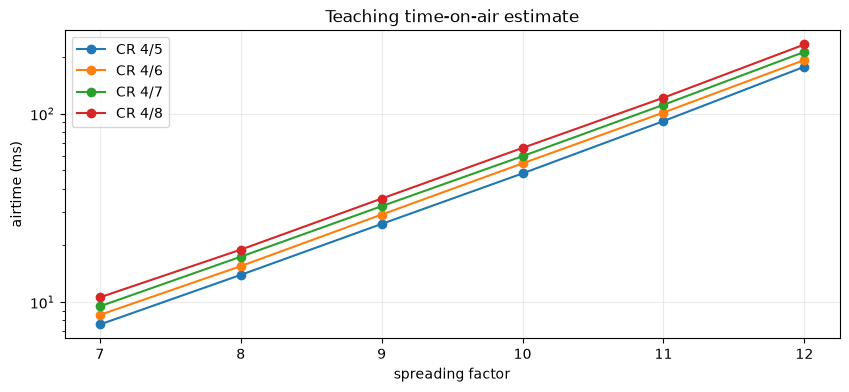

In [4]:
def block_interleave(codewords):
    return codewords.T.reshape(-1)

def block_deinterleave(bits, width):
    return bits.reshape(width, -1).T

def bits_to_symbols(bits, sf):
    padded = np.pad(bits, (0, (-len(bits)) % sf))
    weights = 1 << np.arange(sf - 1, -1, -1)
    return padded.reshape(-1, sf) @ weights

codewords = fec_encode_4_n(whitened_bits, n=5)
interleaved = block_interleave(codewords)
assert np.array_equal(block_deinterleave(interleaved, 5), codewords)
symbols = bits_to_symbols(interleaved, sf=9)

fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(codewords[:24], aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set(title="Teaching FEC-codeword matrix before interleaving", xlabel="bit in codeword", ylabel="codeword")
plt.show()
print(f"SF9: {len(interleaved)} interleaved bits -> {len(symbols)} chirp symbols")

def teaching_toa_s(payload, sf, coding_n=5):
    frame_bits = len(append_crc(payload)) * 8
    coded_bits = int(np.ceil(frame_bits / 4) * coding_n)
    payload_symbols = int(np.ceil(coded_bits / sf))
    return (PREAMBLE_SYMBOLS + 4.25 + payload_symbols) * (1 << sf) / BW_HZ

sf_values = np.arange(7, 13)
fig, ax = plt.subplots()
for coding_n in (5, 6, 7, 8):
    toa_ms = [teaching_toa_s(PAYLOAD, sf, coding_n) * 1e3 for sf in sf_values]
    ax.semilogy(sf_values, toa_ms, marker="o", label=f"CR 4/{coding_n}")
ax.set(title="Teaching time-on-air estimate", xlabel="spreading factor", ylabel="airtime (ms)", xticks=sf_values)
ax.legend()
plt.show()

### See what interleaving buys a sensor report

This diagram follows the existing teaching encoder. Four adjacent damaged channel bits would hit one codeword without interleaving; column-wise transmission spreads them across four codewords. Interleaving adds no parity and does not correct errors by itself. Whether FEC can repair them depends on the code and decoder, which this notebook does not implement.

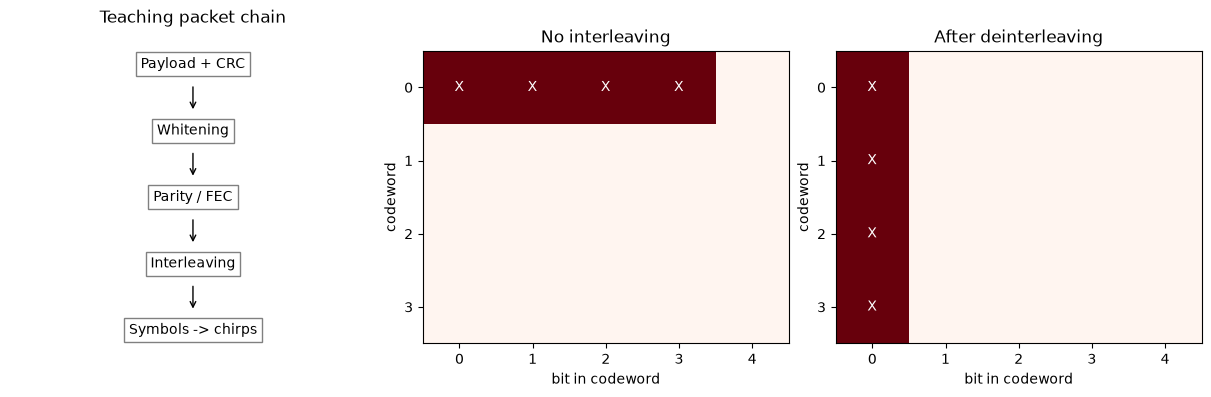

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
steps = ['Payload + CRC', 'Whitening', 'Parity / FEC', 'Interleaving', 'Symbols -> chirps']
for i, label in enumerate(steps):
    y = 4 - i
    axes[0].text(0.5, y, label, ha='center', va='center', bbox=dict(boxstyle='square,pad=0.35', fc='white', ec='0.5'))
    if i < 4:
        axes[0].annotate('', xy=(0.5, y - 0.72), xytext=(0.5, y - 0.3), arrowprops=dict(arrowstyle='->'))
axes[0].set(xlim=(0, 1), ylim=(-0.5, 4.5), title='Teaching packet chain')
axes[0].axis('off')
burst = np.zeros(4 * 5, dtype=np.uint8)
burst[:4] = 1
without_interleaving = burst.reshape(4, 5)
after_deinterleaving = block_deinterleave(burst, 5)
assert np.array_equal(after_deinterleaving.sum(axis=1), np.ones(4))
assert without_interleaving.sum(axis=1).max() == 4
for ax, errors, title in zip(axes[1:], (without_interleaving, after_deinterleaving), ('No interleaving', 'After deinterleaving')):
    ax.imshow(errors, cmap='Reds', vmin=0, vmax=1, aspect='equal')
    for row, col in np.argwhere(errors):
        ax.text(col, row, 'X', color='white', ha='center', va='center')
    ax.set(title=title, xlabel='bit in codeword', ylabel='codeword', xticks=range(5), yticks=range(4))
    ax.grid(False)
plt.show()

## Takeaways

- CRC detects errors; FEC spends airtime to make correction possible.
- Stronger FEC and higher SF both improve robustness at the cost of airtime.
- For bit-exact packet generation, use a verified LoRa implementation or the relevant device datasheet.

Next: [Notebook 2](2_lora_awgn_error_curves.ipynb) measures how the ideal chirp detector behaves in AWGN before adding multipath or Sionna.

**IoT connection:** a short sensor reading still pays preamble, header, CRC, and coding overhead. Keep the payload and retry policy explicit when comparing energy. The airtime curve above is a teaching estimate; Notebook 7 uses the SX126x packet airtime formula.

## Focused references

- J. Tapparel et al., [An Open-Source LoRa Physical Layer Prototype on GNU Radio](https://arxiv.org/abs/2002.08208): complete PHY processing and an implementation against which to check interoperability.
- Semtech, [SX1261/2 datasheet](../../../ref/semtech-sx1261-sx1262-datasheet-2024.pdf): packet format, coding-rate settings, and time-on-air; use the target modem's definitions rather than the teaching encoder.